In [1]:
from compute_icc import *
from pathlib import Path
from plot_icc_boxplots import boxplot_icc_by_feature_group, boxplot_icc_by_function_group, boxplot_features_in_group, heatmap_icc_per_size


In [2]:
source = {
    2: Path("/Users/leekaijen/t7ssd/featELA/dim2featELA/ela_icc_results.pkl"),
    5: Path("/Users/leekaijen/t7ssd/featELA/dim5featELA/ela_icc_results.pkl"),
    10: Path("/Users/leekaijen/t7ssd/featELA/dim10featELA/ela_icc_results.pkl"),
}

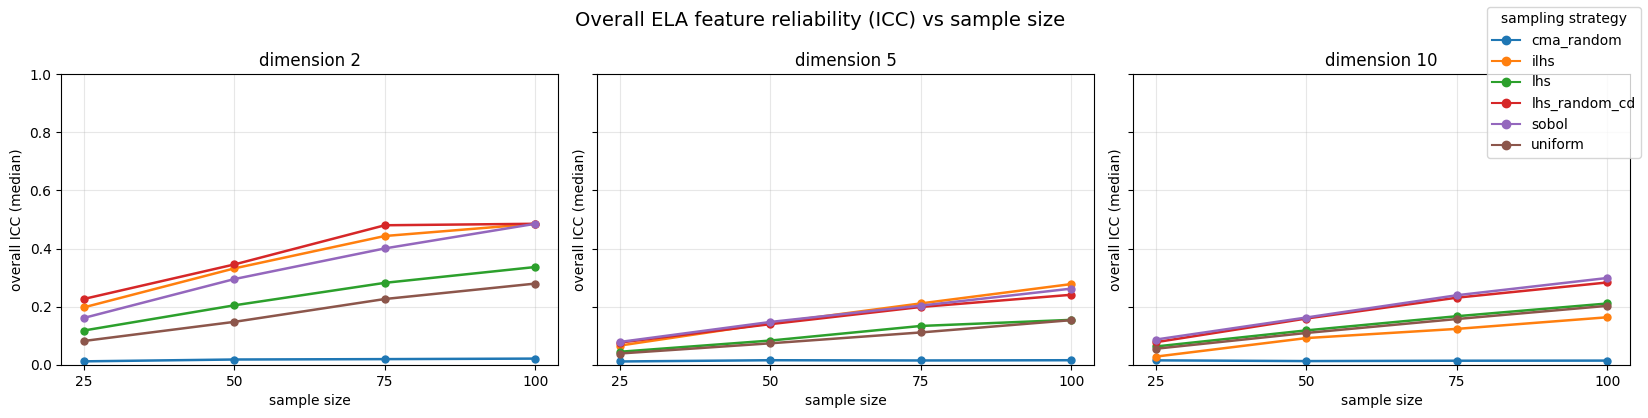

In [3]:
fig = plot_icc_vs_size(source, agg="median")

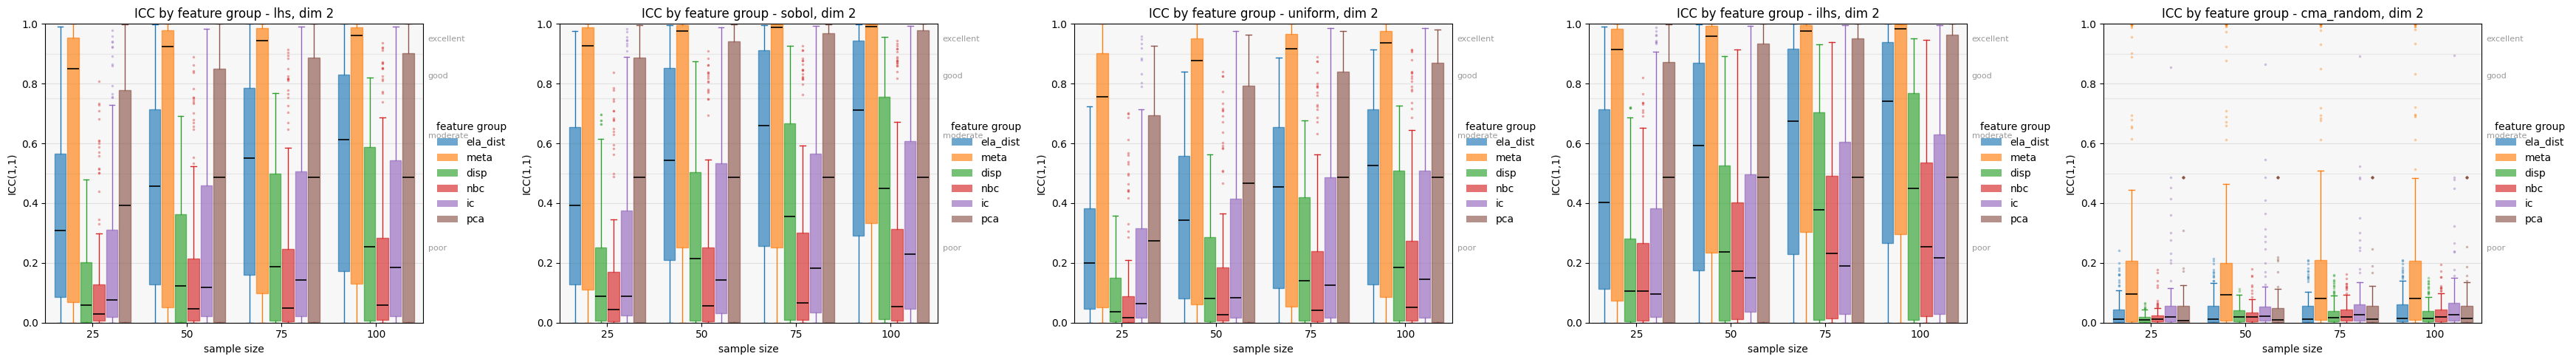

In [4]:
import matplotlib.pyplot as plt
strategies = ["lhs", "sobol", "uniform", "ilhs", "cma_random"]
fig, axes = plt.subplots(1, len(strategies), figsize=(7*len(strategies), 5), sharey=False)
for ax, st in zip(axes, strategies):
    boxplot_icc_by_feature_group(source, dimension=2, strategy=st, ax=ax)


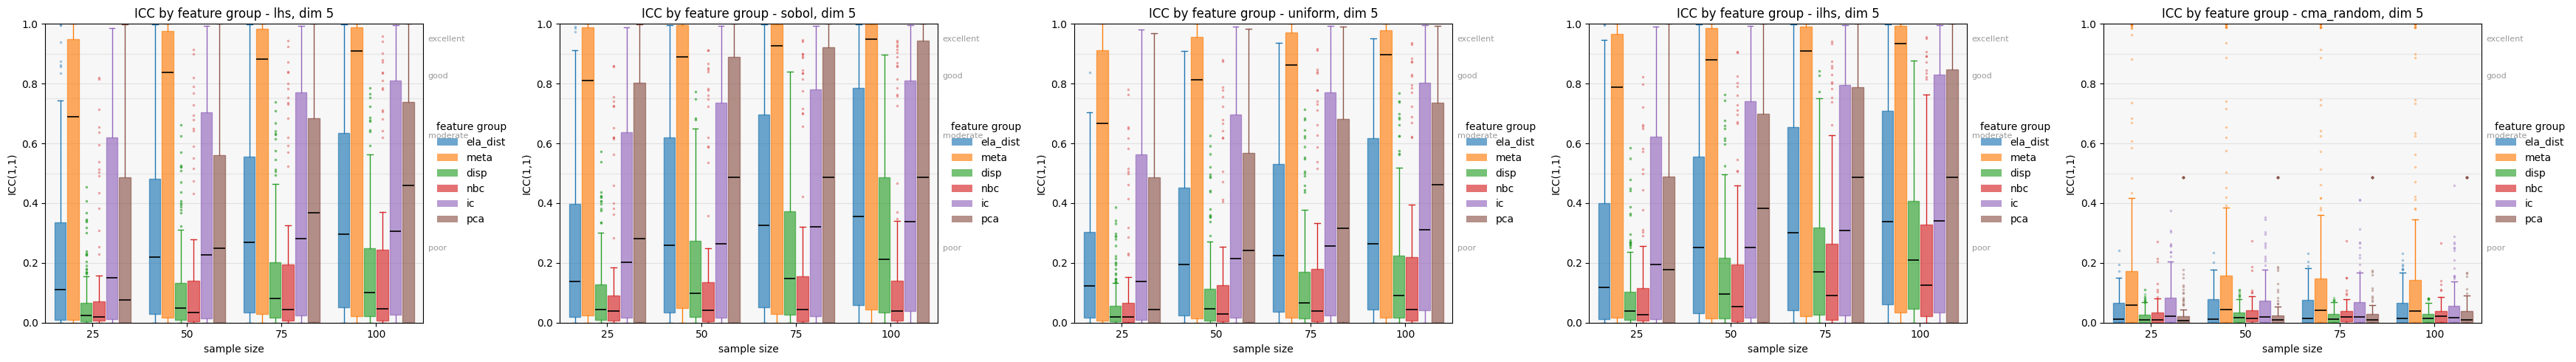

In [5]:
import matplotlib.pyplot as plt
strategies = ["lhs", "sobol", "uniform", "ilhs", "cma_random"]
fig, axes = plt.subplots(1, len(strategies), figsize=(7*len(strategies), 5), sharey=False)
for ax, st in zip(axes, strategies):
    boxplot_icc_by_feature_group(source, dimension=5, strategy=st, ax=ax)


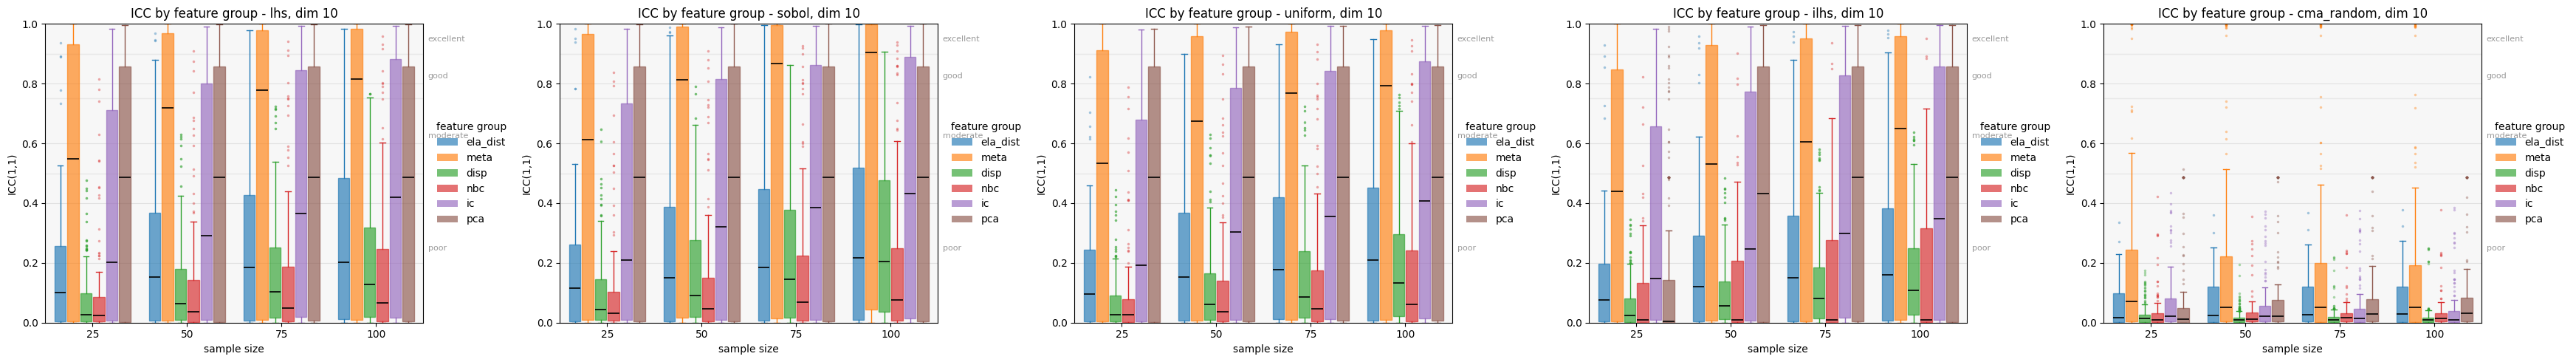

In [6]:
import matplotlib.pyplot as plt
strategies = ["lhs", "sobol", "uniform", "ilhs", "cma_random"]
fig, axes = plt.subplots(1, len(strategies), figsize=(7*len(strategies), 5), sharey=False)
for ax, st in zip(axes, strategies):
    boxplot_icc_by_feature_group(source, dimension=10, strategy=st, ax=ax)


## Feature Group

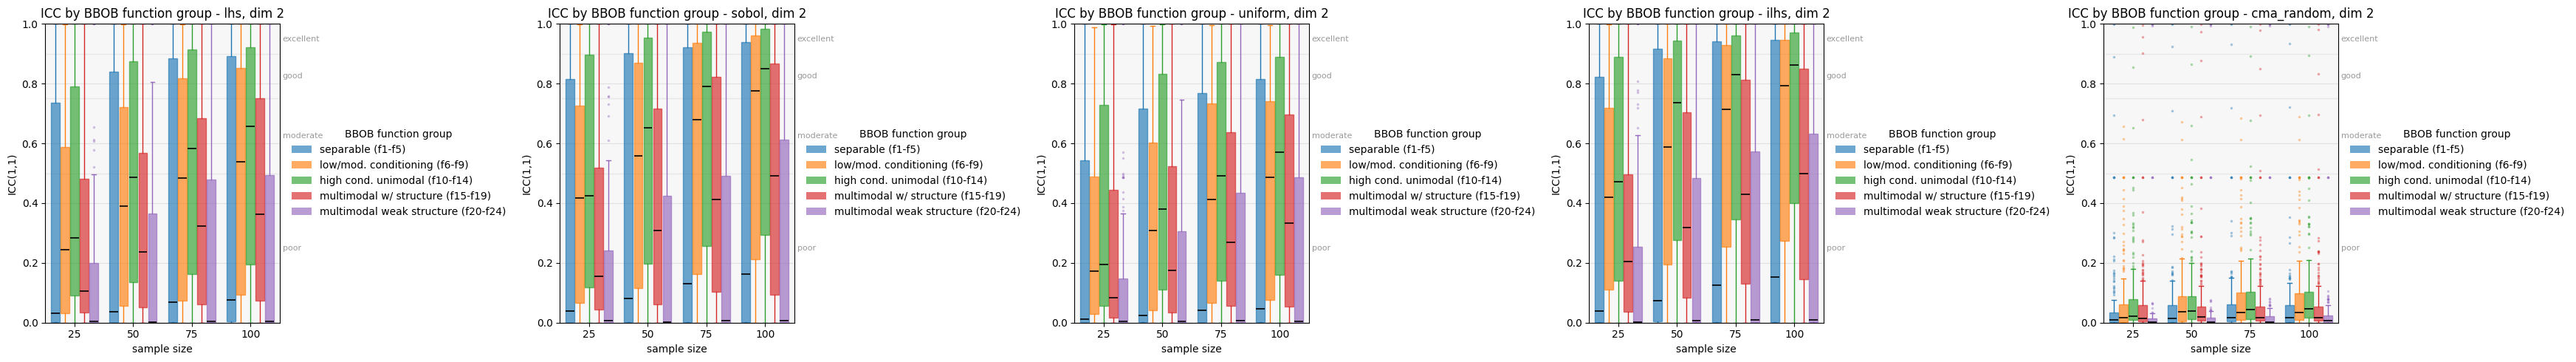

In [7]:
fig, axes = plt.subplots(1, len(strategies), figsize=(7*len(strategies), 5), sharey=False)
for ax, st in zip(axes, strategies):
    boxplot_icc_by_function_group(source, dimension=2, strategy=st, ax=ax)

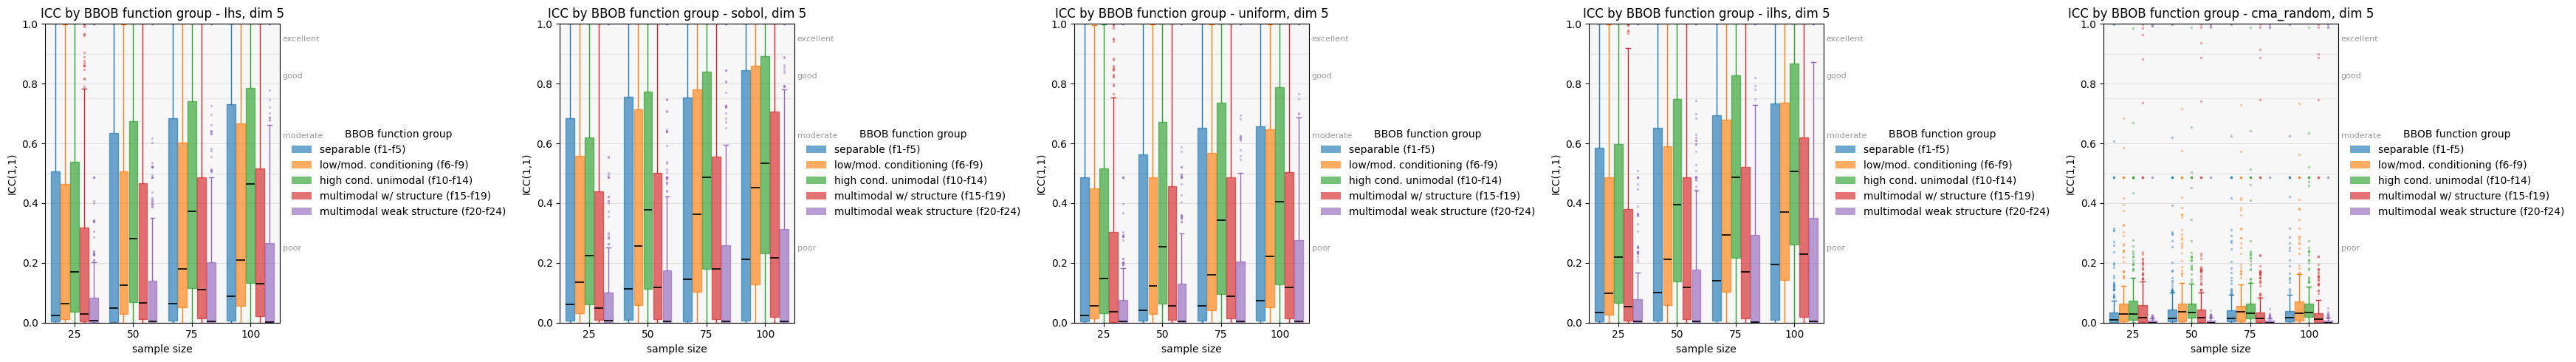

In [8]:
fig, axes = plt.subplots(1, len(strategies), figsize=(7*len(strategies), 5), sharey=False)
for ax, st in zip(axes, strategies):
    boxplot_icc_by_function_group(source, dimension=5, strategy=st, ax=ax)

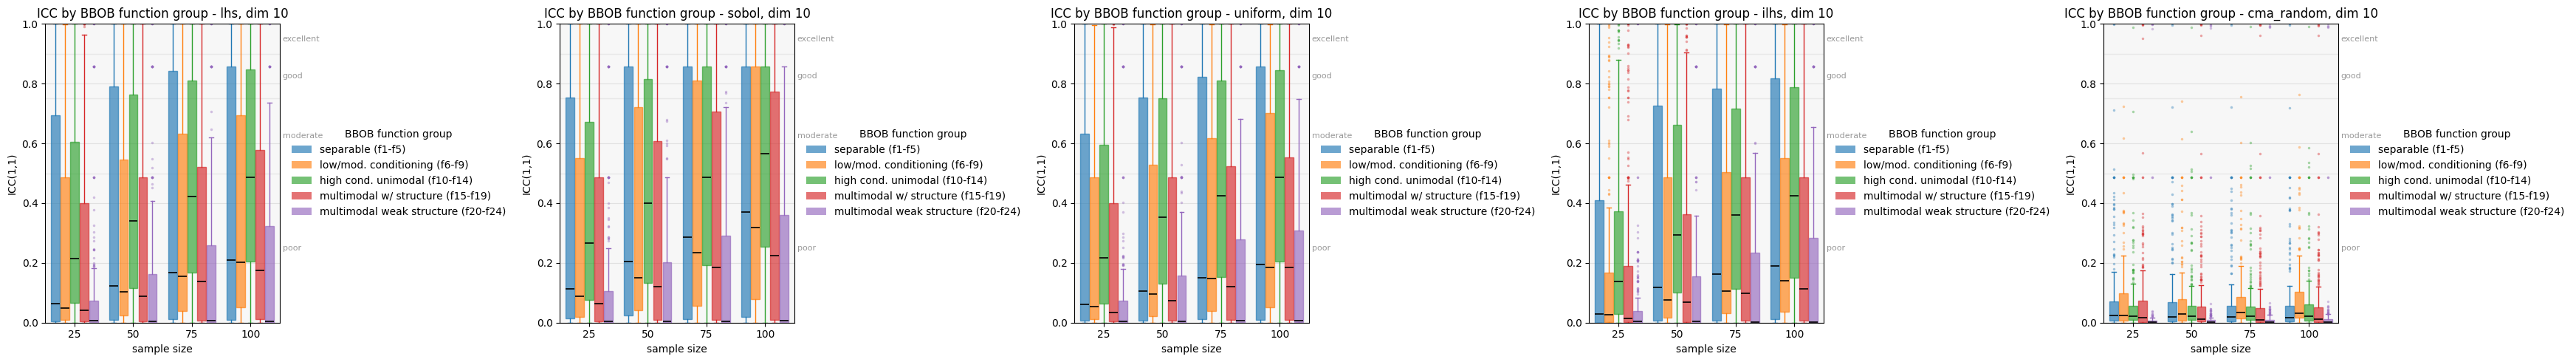

In [9]:
fig, axes = plt.subplots(1, len(strategies), figsize=(7*len(strategies), 5), sharey=False)
for ax, st in zip(axes, strategies):
    boxplot_icc_by_function_group(source, dimension=10, strategy=st, ax=ax)

In [10]:
from icc_nan_analysis import nan_icc_report

detail, summary = nan_icc_report(source, dimension=2, verbose=True)
summary    # one row per (strategy, size)
detail     # one row per (strategy, size, func) that has >=1 NaN

dim 2: 1194 NaN ICC cells / 23040 (5.18%); 24/24 (strategy, size) configs and 488 (strategy, size, func) rows affected.


,strategy,size,func,n_nan,n_cells,frac_nan,nan_features
0,cma_random,25,1,2,40,0.050,"ela_meta.quad_simple.adj_r2, ela_meta.quad_w_i..."
1,cma_random,25,5,4,40,0.100,"ela_meta.lin_simple.adj_r2, ela_meta.lin_w_int..."
2,cma_random,50,1,2,40,0.050,"ela_meta.quad_simple.adj_r2, ela_meta.quad_w_i..."
3,cma_random,50,5,4,40,0.100,"ela_meta.lin_simple.adj_r2, ela_meta.lin_w_int..."
4,cma_random,75,1,2,40,0.050,"ela_meta.quad_simple.adj_r2, ela_meta.quad_w_i..."
...,...,...,...,...,...,...,...
483,uniform,100,20,2,40,0.050,"pca.expl_var.cor_x, pca.expl_var.cov_x"
484,uniform,100,21,3,40,0.075,"pca.expl_var.cor_init, pca.expl_var.cor_x, pca..."
485,uniform,100,22,2,40,0.050,"pca.expl_var.cor_x, pca.expl_var.cov_x"
486,uniform,100,23,3,40,0.075,"pca.expl_var.cor_init, pca.expl_var.cor_x, pca..."


In [11]:
summary

,strategy,size,n_nan,n_cells,frac_nan,n_funcs_affected,n_funcs_total,n_features_affected,top_features
0,cma_random,25,6,960,0.006250,2,24,4,"ela_meta.quad_simple.adj_r2 (2), ela_meta.quad..."
1,cma_random,50,6,960,0.006250,2,24,4,"ela_meta.quad_simple.adj_r2 (2), ela_meta.quad..."
2,cma_random,75,6,960,0.006250,2,24,4,"ela_meta.quad_simple.adj_r2 (2), ela_meta.quad..."
3,cma_random,100,6,960,0.006250,2,24,4,"ela_meta.quad_simple.adj_r2 (2), ela_meta.quad..."
4,ilhs,25,58,960,0.060417,24,24,7,"pca.expl_var.cov_x (24), pca.expl_var.cor_x (2..."
5,ilhs,50,59,960,0.061458,24,24,7,"pca.expl_var.cov_x (24), pca.expl_var.cor_x (2..."
6,ilhs,75,59,960,0.061458,24,24,7,"pca.expl_var.cov_x (24), pca.expl_var.cor_x (2..."
7,ilhs,100,59,960,0.061458,24,24,7,"pca.expl_var.cov_x (24), pca.expl_var.cor_x (2..."
8,lhs,25,56,960,0.058333,24,24,7,"pca.expl_var.cov_x (24), pca.expl_var.cor_x (2..."
9,lhs,50,59,960,0.061458,24,24,7,"pca.expl_var.cov_x (24), pca.expl_var.cor_x (2..."


In [12]:
import pickle
def get_omit_features(dimension):
    if dimension == 2:
        return {
            'disp.diff_median_02', 'disp.ratio_median_02',
            'disp.ratio_mean_02', 'ela_meta.quad_simple.cond',
            'disp.diff_mean_02', 'ic.eps_ratio'
        }
    elif dimension in (5, 10):
        return {'ela_meta.quad_simple.cond'}
    return set()

d = pickle.load(open(source[5], "rb"))
present = {f for bf in d.values() for bg in bf.values()
           for grp in bg.values() for f in grp}
        # or paste the set
leaked = present & get_omit_features(2)
print("dims in pkl:", {k[1] for bf in d.values() for k in bf})
print("omit features that leaked into the pkl:", sorted(leaked))

dims in pkl: {5}
omit features that leaked into the pkl: ['disp.diff_mean_02', 'disp.diff_median_02', 'disp.ratio_mean_02', 'disp.ratio_median_02', 'ic.eps_ratio']


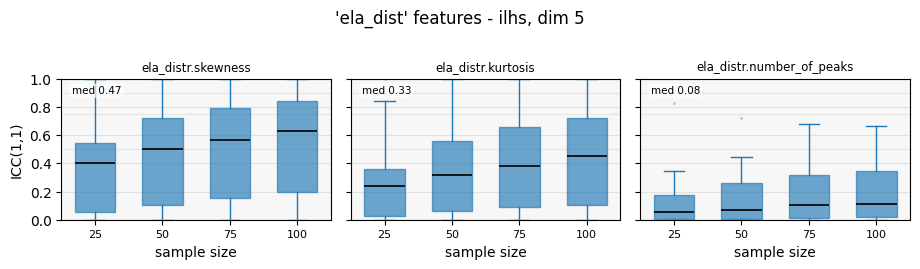

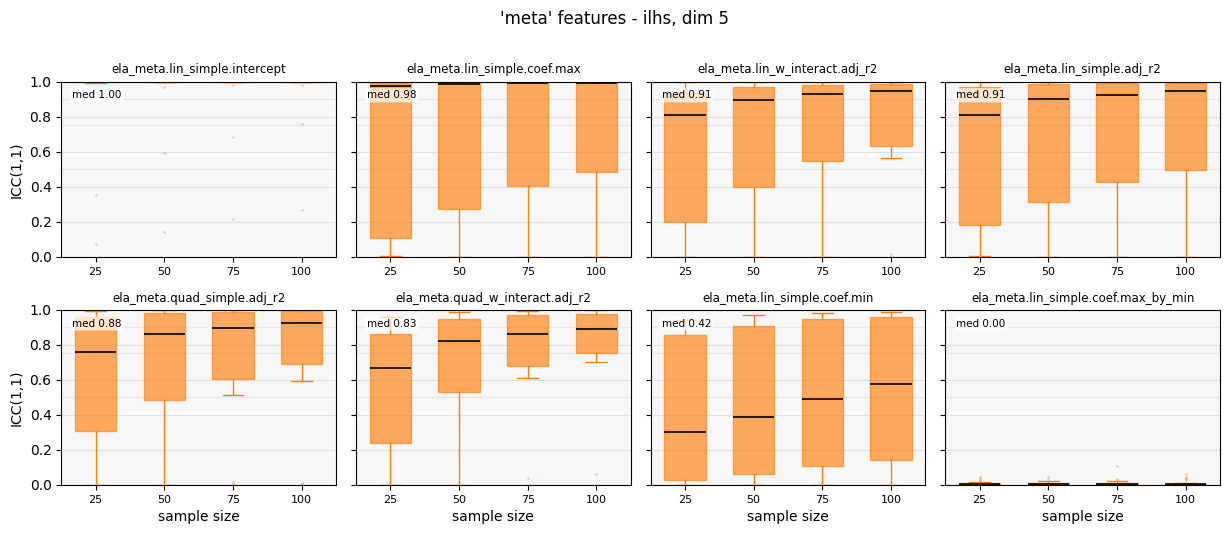

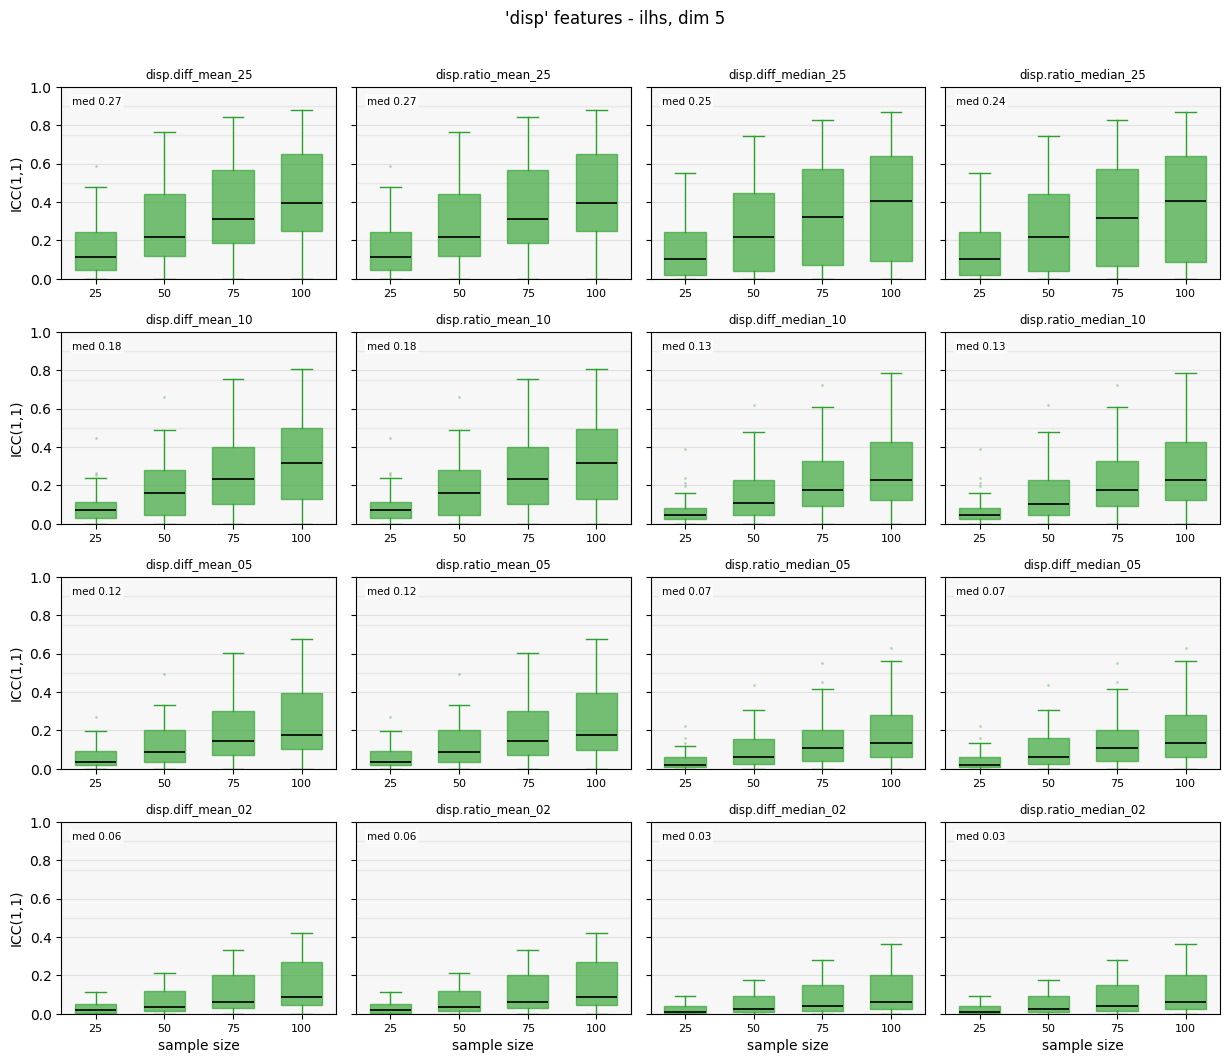

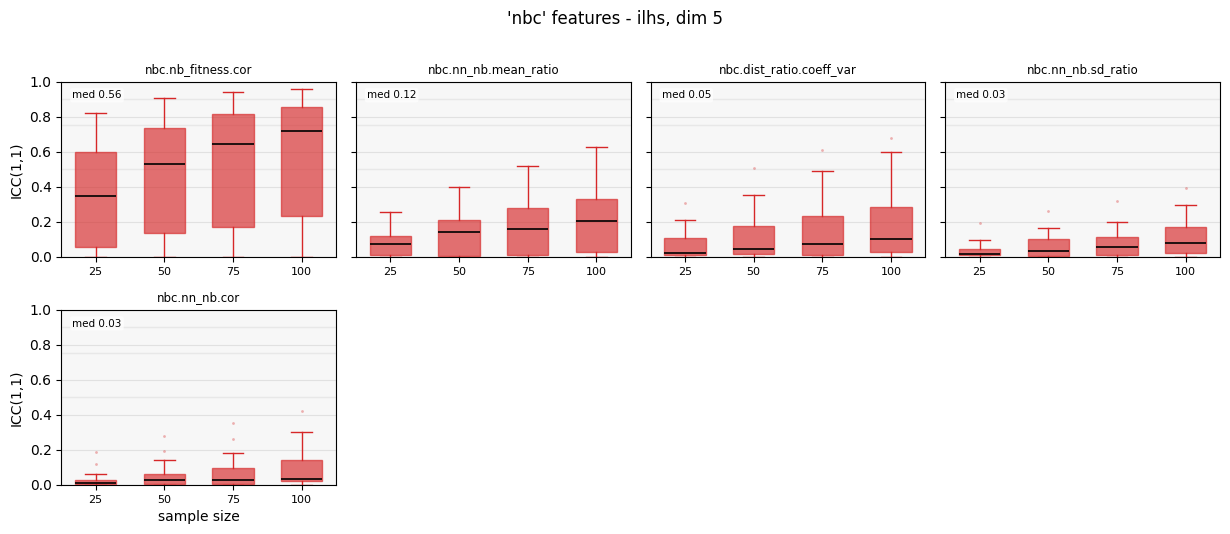

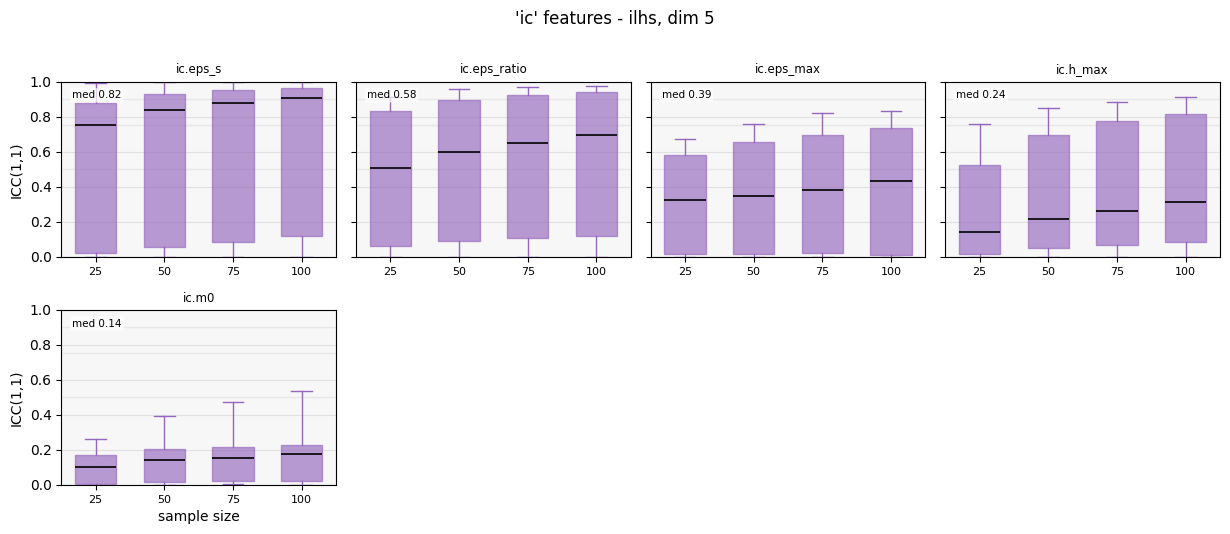

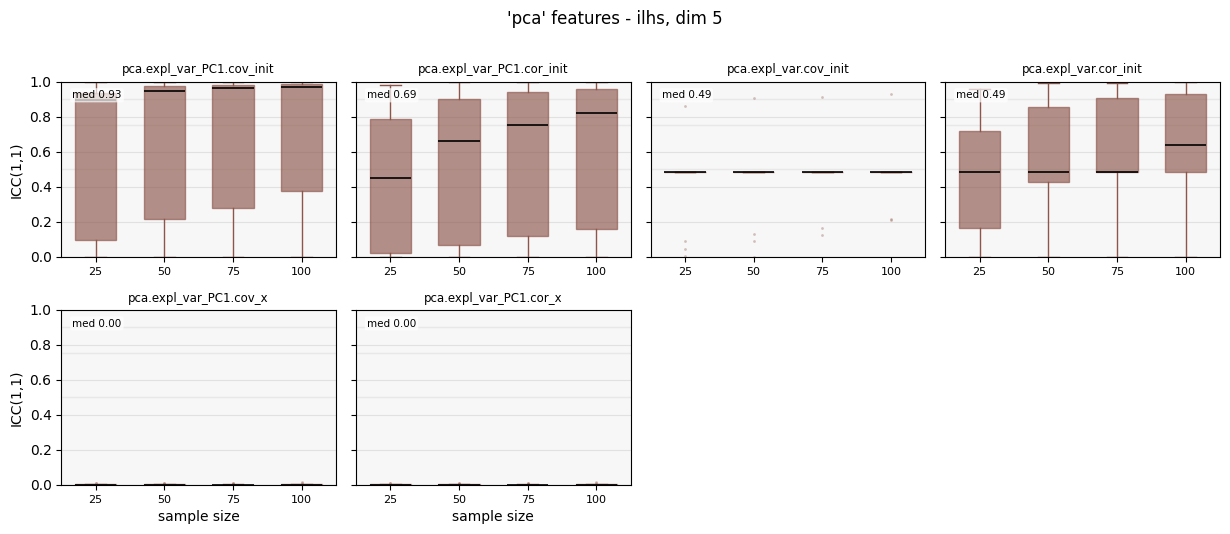

In [13]:
for group in ["ela_dist", "meta", "disp", "nbc", "ic", "pca"]:
    fig, axes = boxplot_features_in_group(source, dimension=5, strategy="ilhs",
                                      feature_group=group)
    plt.show()

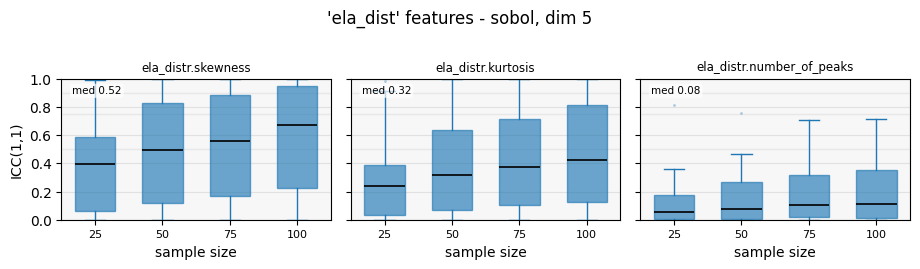

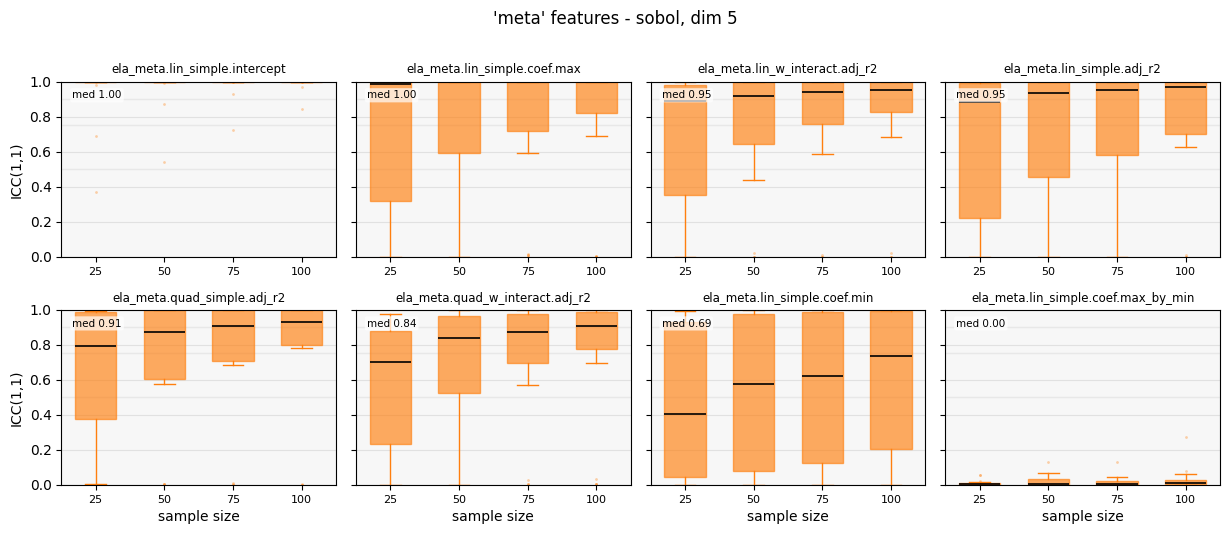

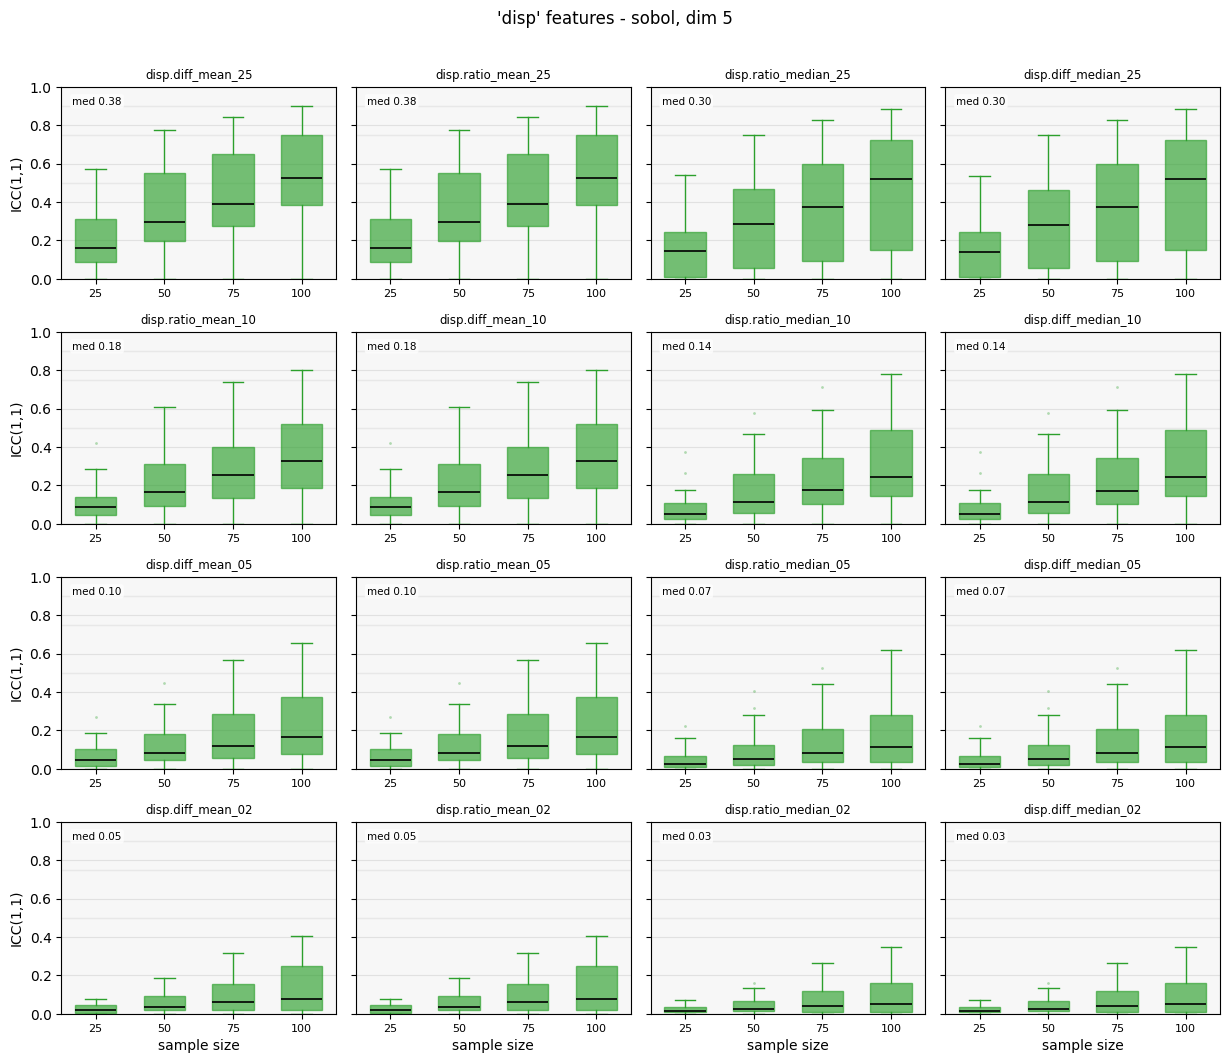

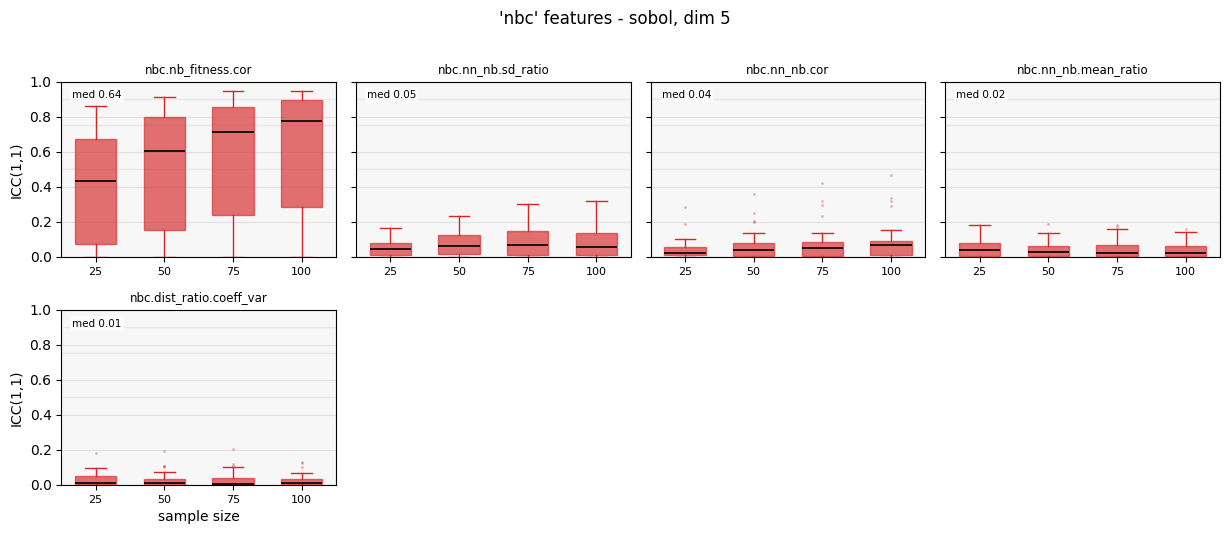

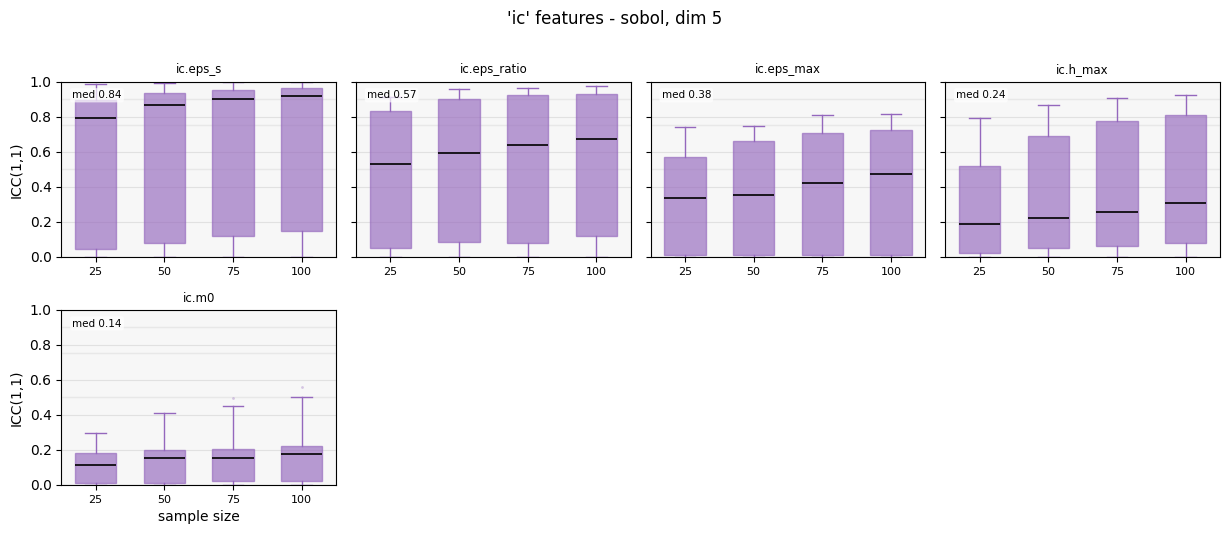

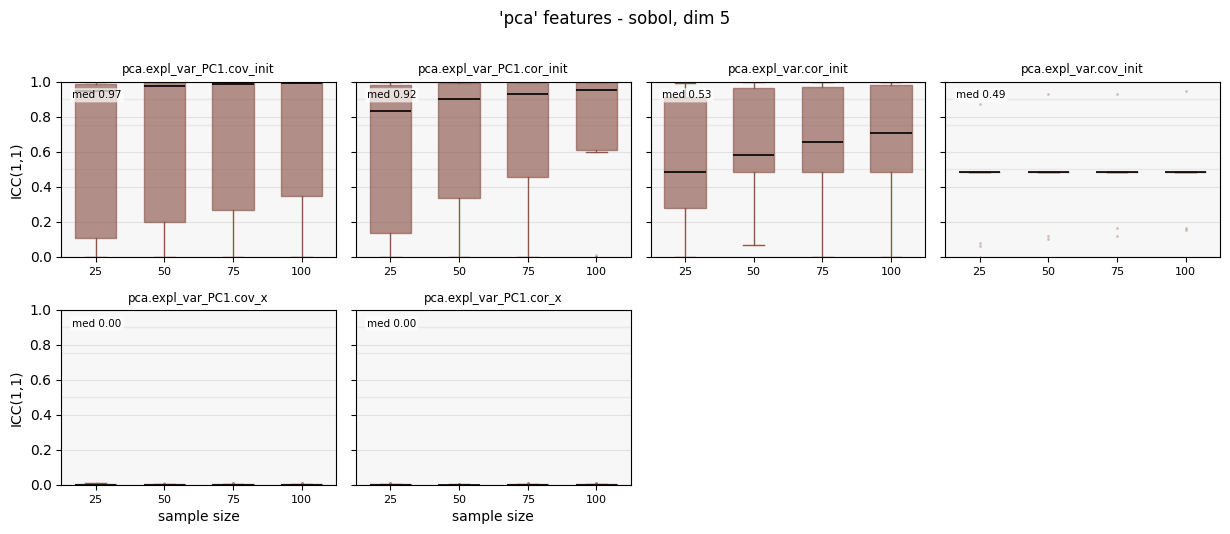

In [14]:
for group in ["ela_dist", "meta", "disp", "nbc", "ic", "pca"]:
    fig, axes = boxplot_features_in_group(source, dimension=5, strategy="sobol",
                                      feature_group=group)
    plt.show()

(<Figure size 1840x1690 with 5 Axes>,
 array([[<Axes: title={'center': 'n = 25'}, xlabel='BBOB function'>,
         <Axes: title={'center': 'n = 50'}, xlabel='BBOB function'>,
         <Axes: title={'center': 'n = 75'}, xlabel='BBOB function'>,
         <Axes: title={'center': 'n = 100'}, xlabel='BBOB function'>]],
       dtype=object))

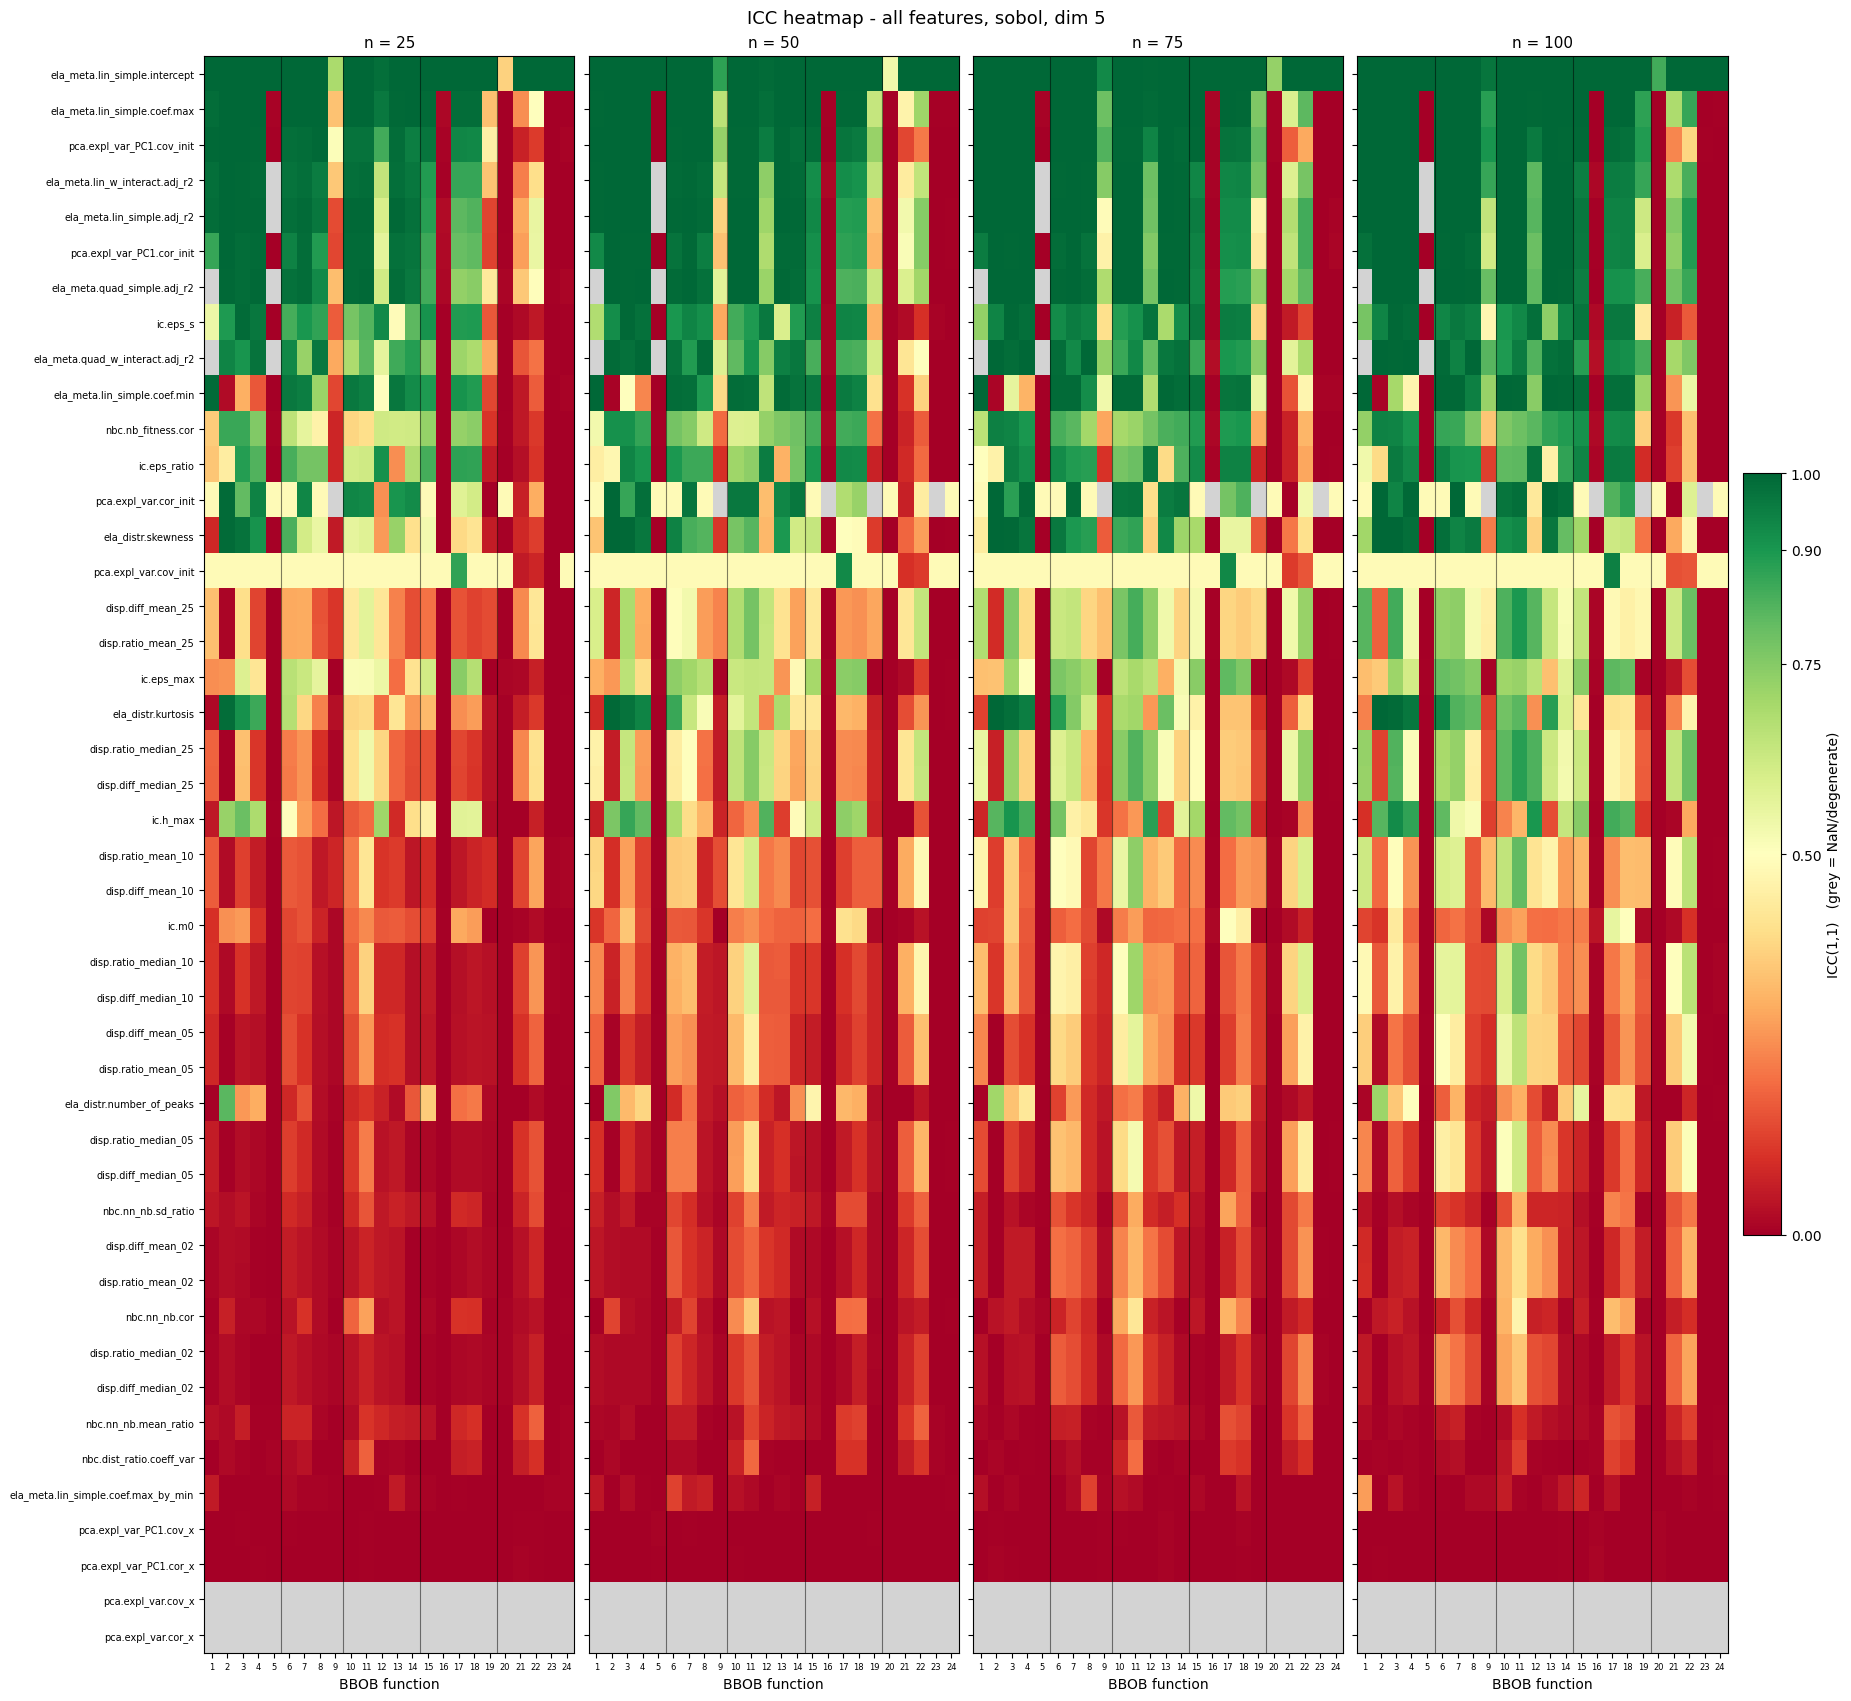

In [15]:
heatmap_icc_per_size(source, dimension=5, strategy="sobol")


(<Figure size 1840x1690 with 5 Axes>,
 array([[<Axes: title={'center': 'n = 25'}, xlabel='BBOB function'>,
         <Axes: title={'center': 'n = 50'}, xlabel='BBOB function'>,
         <Axes: title={'center': 'n = 75'}, xlabel='BBOB function'>,
         <Axes: title={'center': 'n = 100'}, xlabel='BBOB function'>]],
       dtype=object))

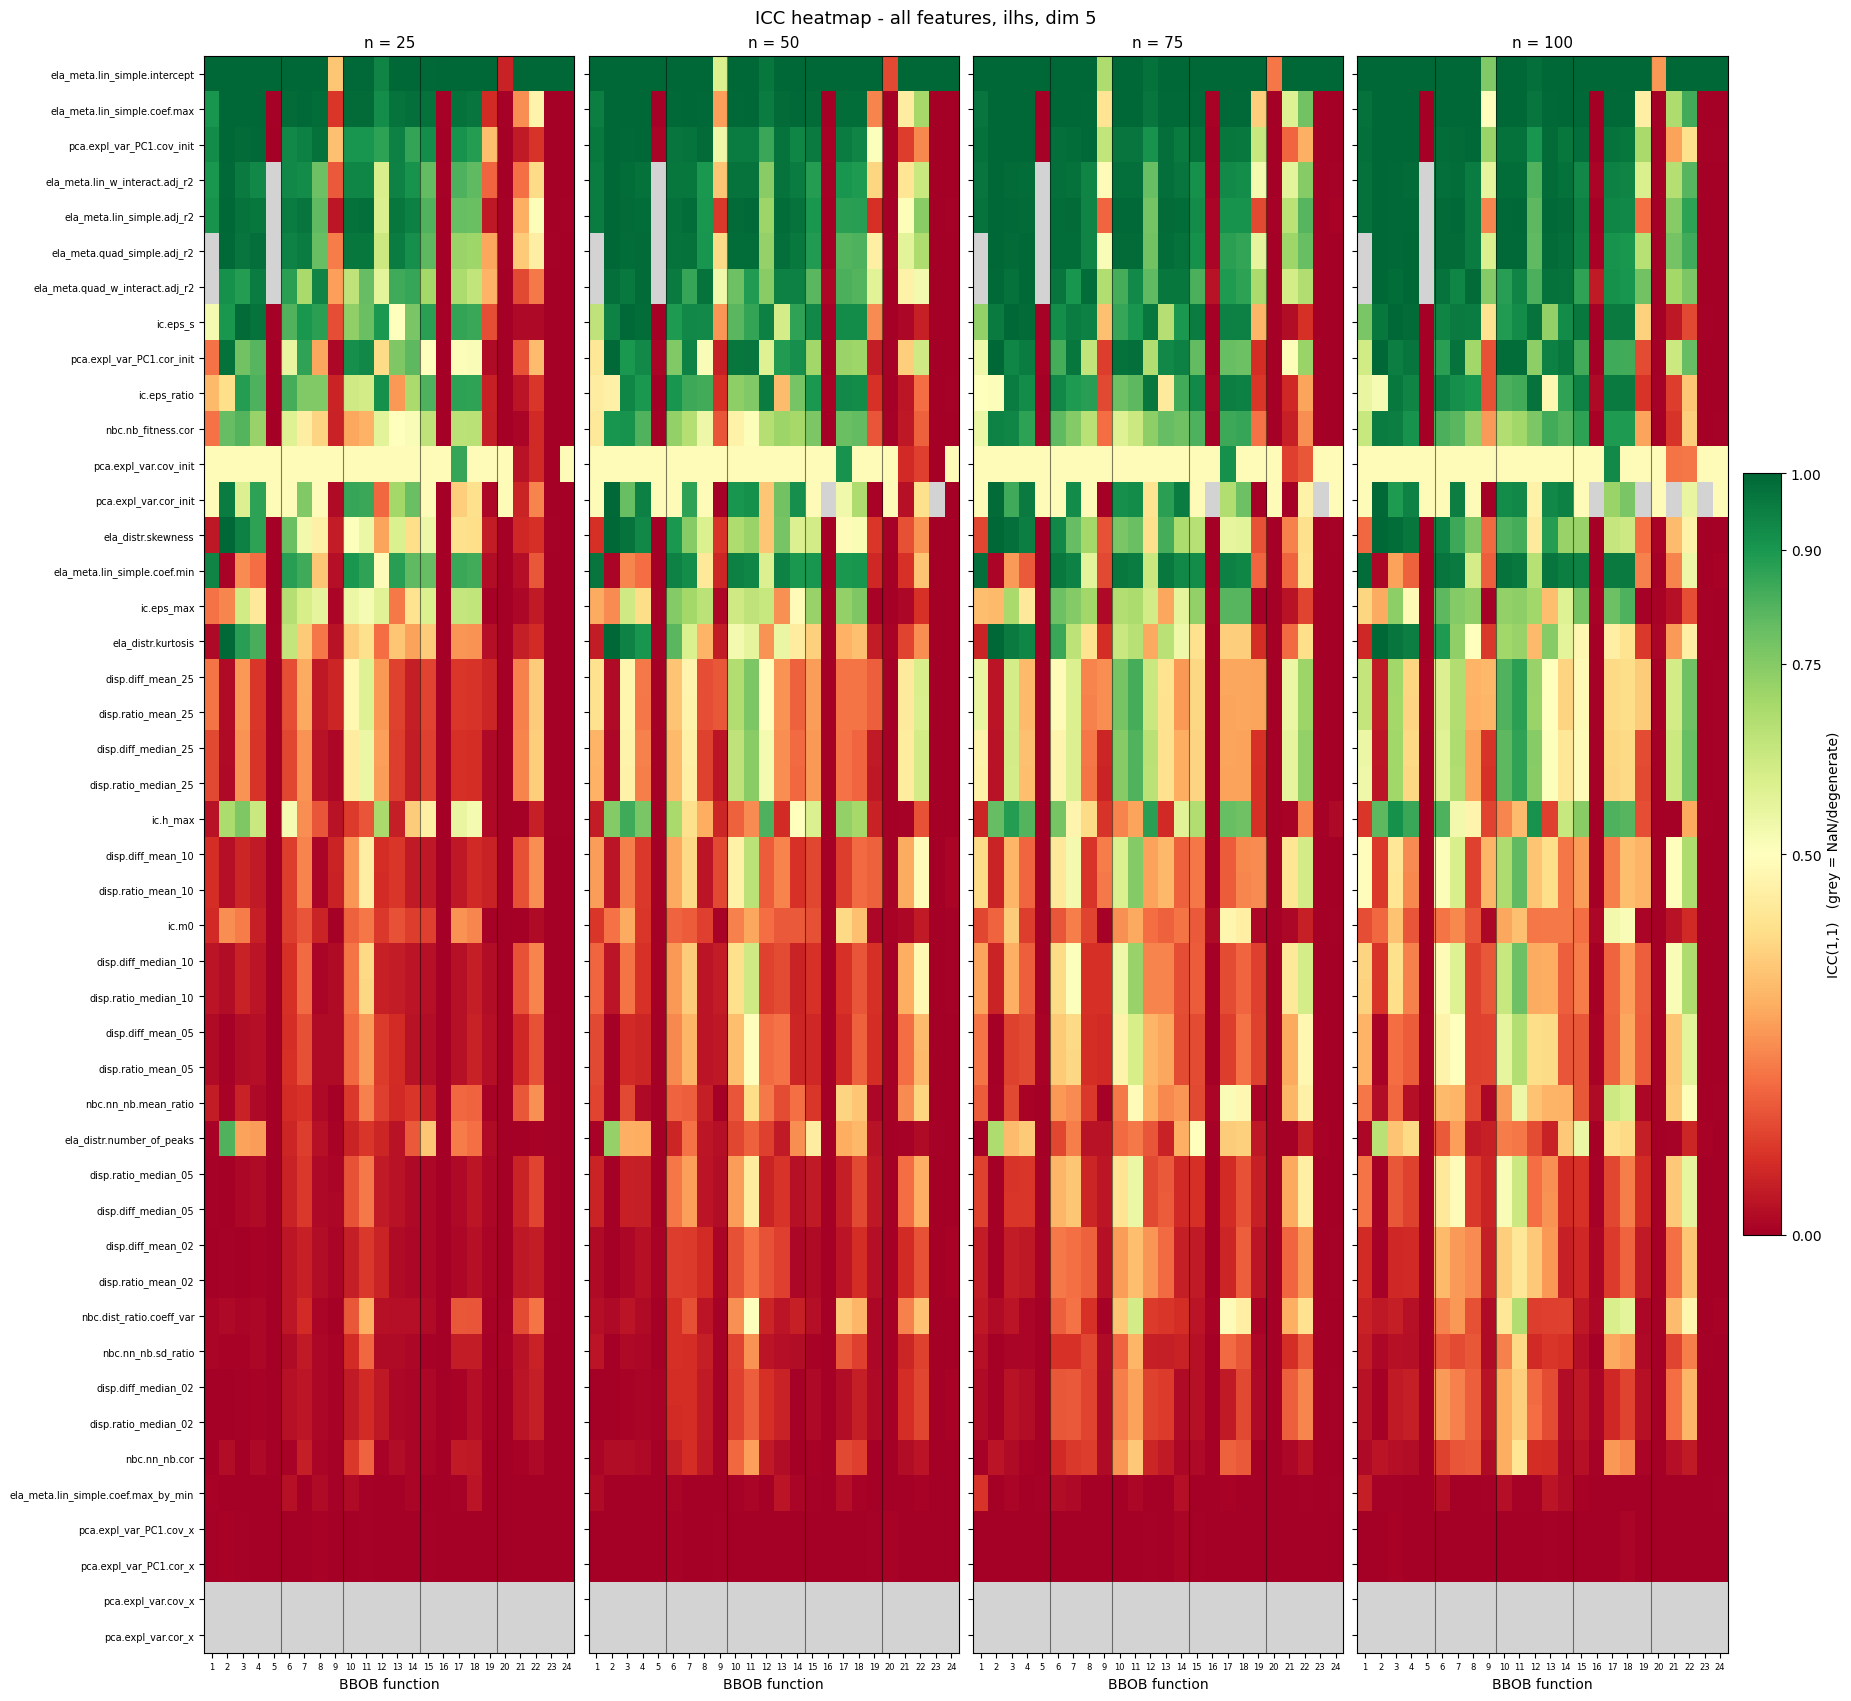

In [16]:
heatmap_icc_per_size(source, dimension=5, strategy="ilhs")


(<Figure size 1840x1690 with 5 Axes>,
 array([[<Axes: title={'center': 'n = 25'}, xlabel='BBOB function'>,
         <Axes: title={'center': 'n = 50'}, xlabel='BBOB function'>,
         <Axes: title={'center': 'n = 75'}, xlabel='BBOB function'>,
         <Axes: title={'center': 'n = 100'}, xlabel='BBOB function'>]],
       dtype=object))

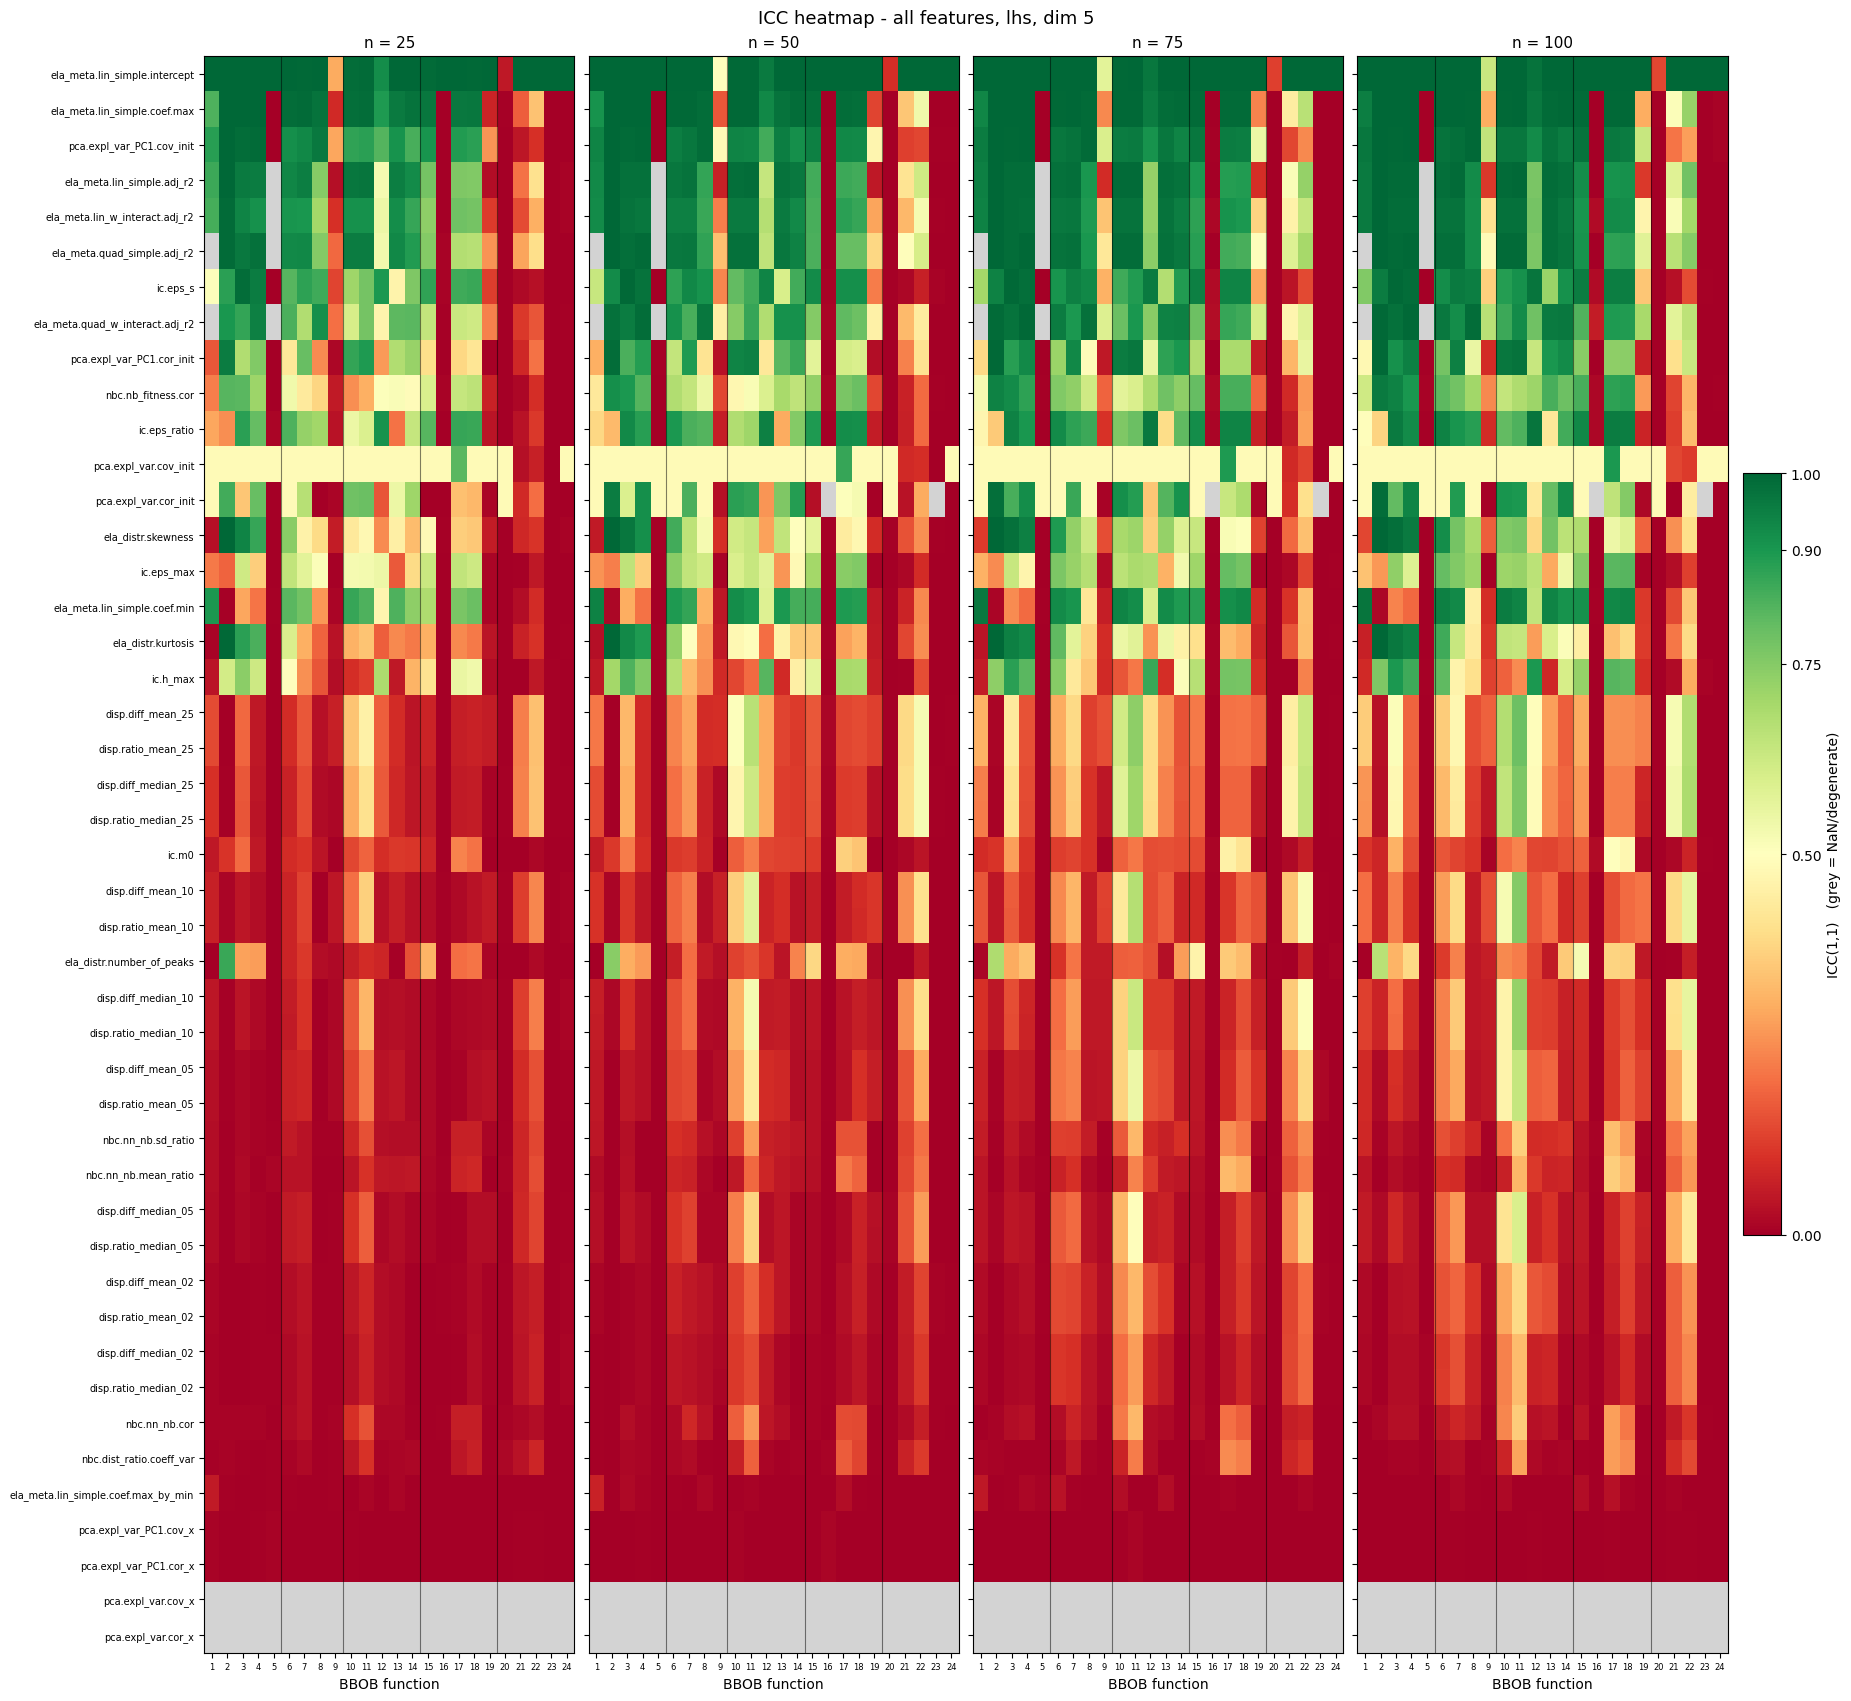

In [17]:
heatmap_icc_per_size(source, dimension=5, strategy="lhs")


(<Figure size 1840x1690 with 5 Axes>,
 array([[<Axes: title={'center': 'n = 25'}, xlabel='BBOB function'>,
         <Axes: title={'center': 'n = 50'}, xlabel='BBOB function'>,
         <Axes: title={'center': 'n = 75'}, xlabel='BBOB function'>,
         <Axes: title={'center': 'n = 100'}, xlabel='BBOB function'>]],
       dtype=object))

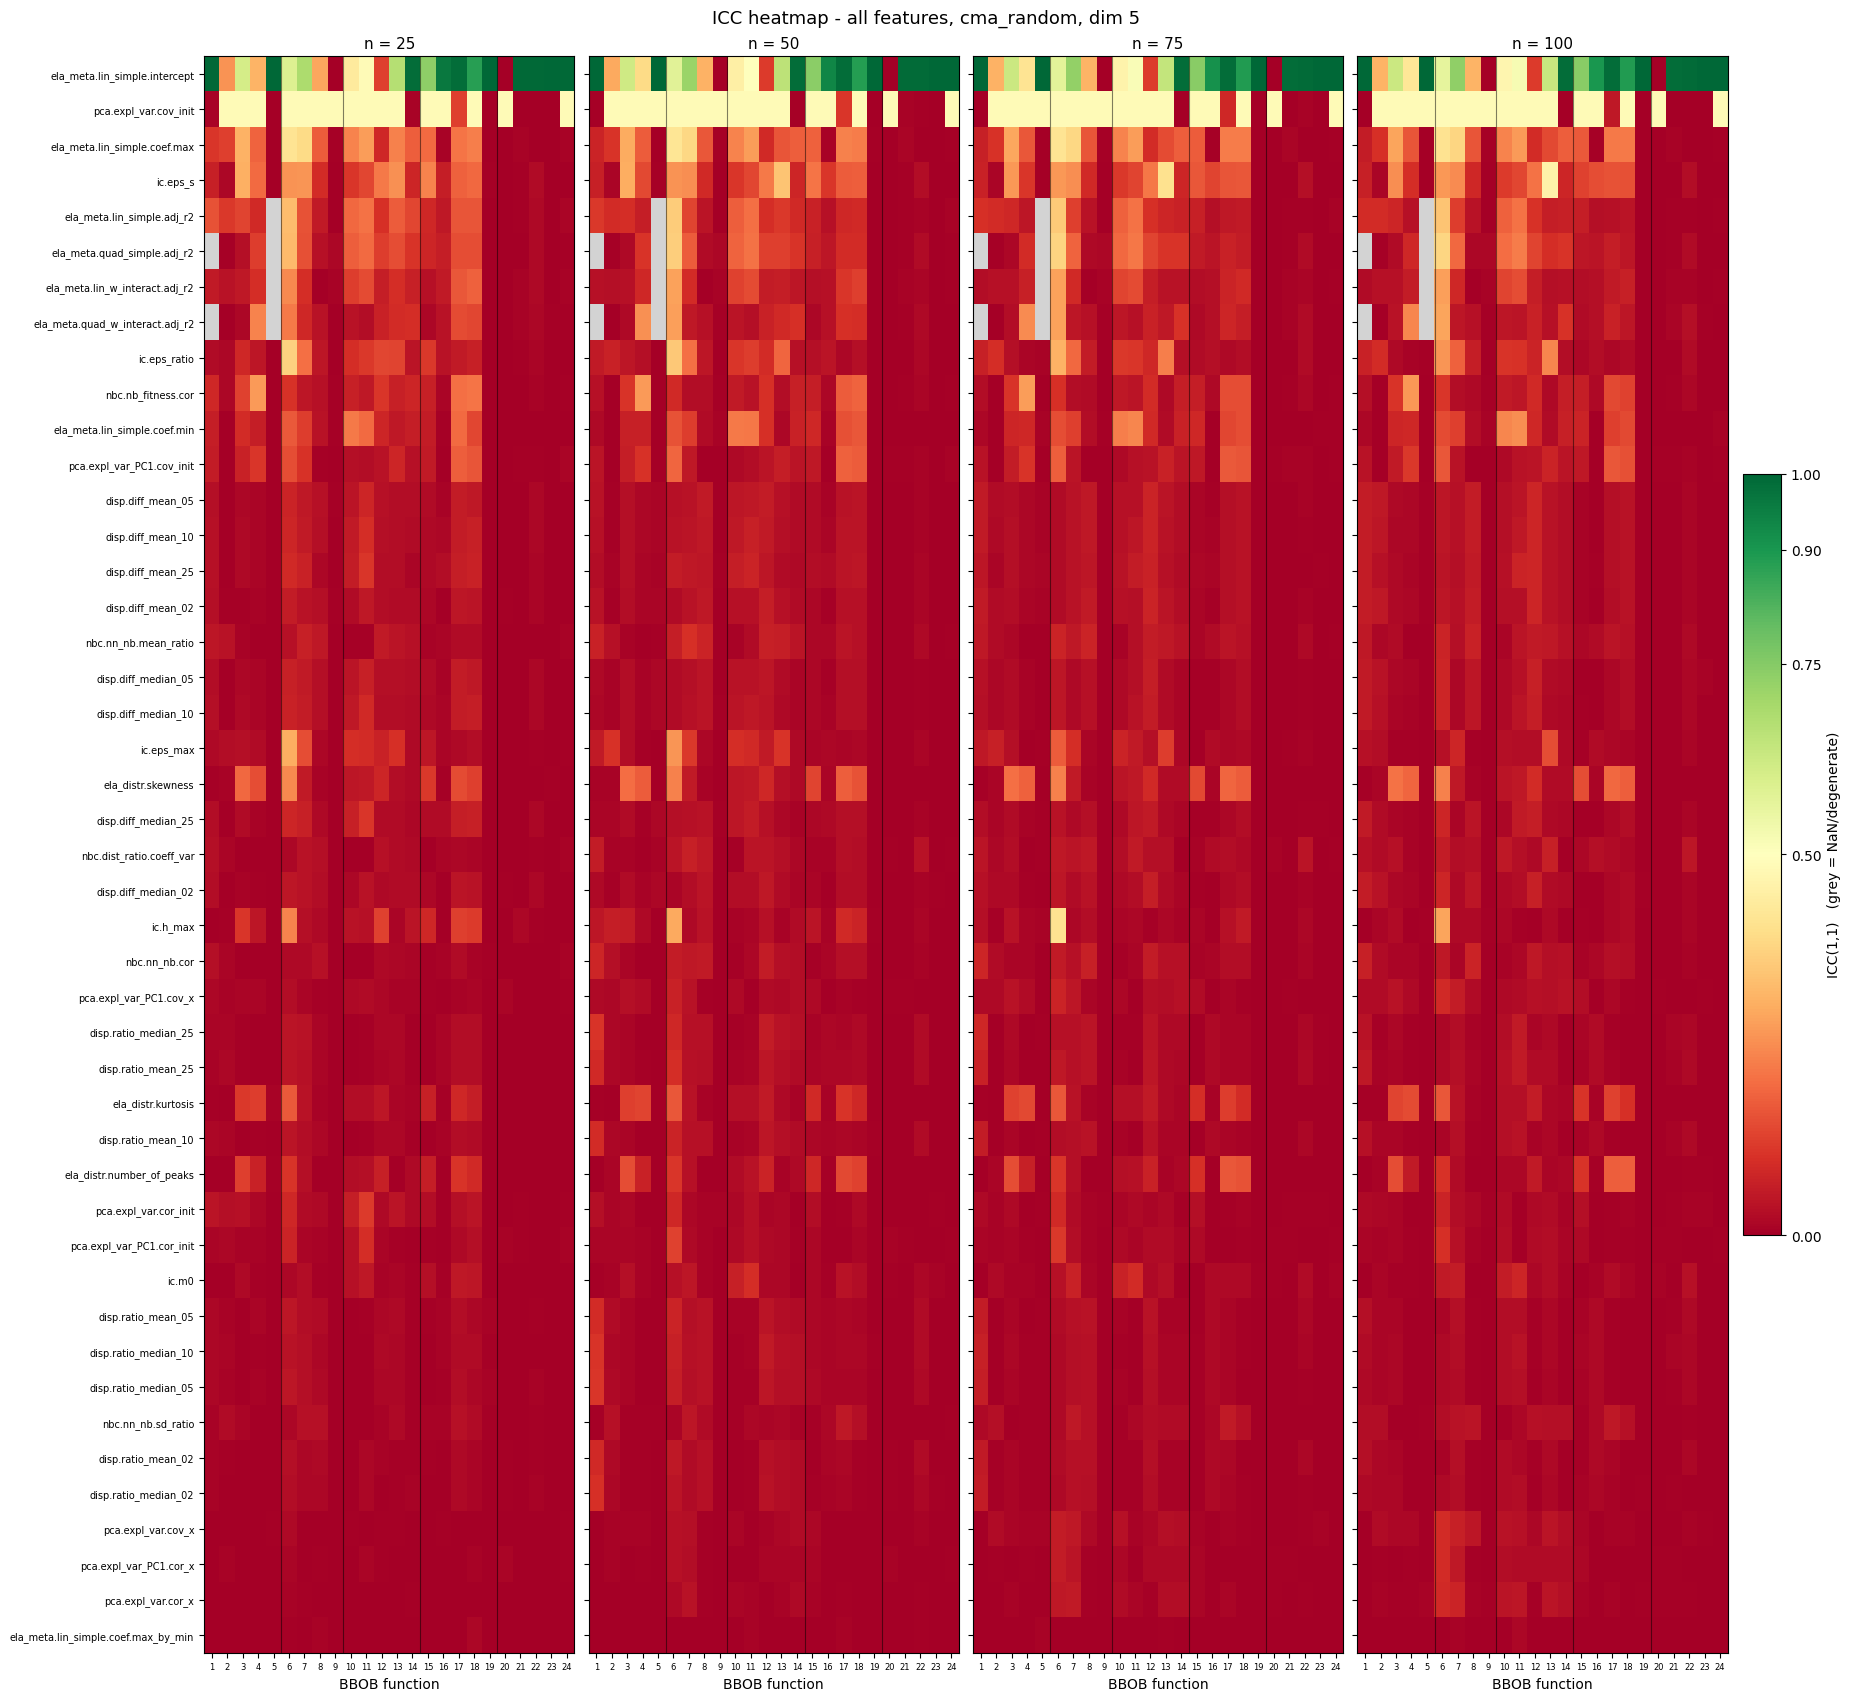

In [18]:
heatmap_icc_per_size(source, dimension=5, strategy="cma_random")
